# Malaria Diagnosis: Building and Training the ANN

Same structure as `02_ann_training.ipynb` from the diabetes project. All
the data work is already done, this notebook only focuses on the network:

1. Load the prepared data (from CSV)
2. Build the ANN
3. Train it
4. Visualize training
5. Evaluate on the test set (ROC curve, confusion matrix)
6. Save the trained model
7. Make a clean, simple prediction on a new patient

Run `01_malaria_data_preparation.ipynb` first if you haven't already.


## Step 1: Import libraries

In [4]:
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

tf.random.set_seed(42)
np.random.seed(42)


## Step 2: Load the prepared data

We train directly from the CSV files the data preparation notebook
saved. The small preprocessing details (feature order, imputation median,
scaler numbers) come from the JSON metadata file.

In [5]:
train_df = pd.read_csv('malaria_train.csv')
val_df = pd.read_csv('malaria_val.csv')
test_df = pd.read_csv('malaria_test.csv')

with open('malaria_metadata.json') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
train_medians = metadata['train_medians']
scaler_mean = np.array(metadata['scaler_mean'], dtype=np.float32)
scaler_scale = np.array(metadata['scaler_scale'], dtype=np.float32)

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df['Malaria_Positive'].values.astype(np.float32)
X_val = val_df[feature_cols].values.astype(np.float32)
y_val = val_df['Malaria_Positive'].values.astype(np.float32)
X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df['Malaria_Positive'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")


Train: (560, 15)
Val:   (120, 15)
Test:  (120, 15)
Number of features: 15


## Step 3: Build the ANN

Same architecture family as the diabetes model: Dense blocks with
BatchNormalization, ReLU, and Dropout, ending in a single sigmoid output
neuron (a probability of malaria).

In [6]:
def build_ann(n_features):
    inputs = keras.Input(shape=(n_features,), name='features')

    x = keras.layers.Dense(128, kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    x = keras.layers.Dense(64, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    x = keras.layers.Dense(32)(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(x)

    return keras.Model(inputs, outputs, name='MalariaANN')


model = build_ann(X_train.shape[1])
model.summary()


Model: "MalariaANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 15)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 384 (1.50 KB)

## Step 4: Compile the model

Adam optimizer, binary cross-entropy loss (this is a yes/no diagnosis
problem, so this pairing is the right one, as we covered in the diabetes
notebook), and a few metrics to track.

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)


## Step 5: Train the model

Same three callbacks as the diabetes notebook: stop early once validation
AUC stops improving, shrink the learning rate when progress stalls, and
keep only the best checkpoint.

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=25,
        restore_best_weights=True, mode='max', verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=10,
        min_lr=1e-6, mode='max', verbose=1),
    keras.callbacks.ModelCheckpoint(
        'best_malaria.keras', monitor='val_auc',
        save_best_only=True, mode='max', verbose=0),
]

history = model.fit(
    X_train, y_train,
    epochs=300, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEpochs run:   {len(history.history['loss'])}")
print(f"Best val AUC: {max(history.history['val_auc']):.4f}")


Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6732 - auc: 0.6743 - loss: 0.6996 - precision: 0.8049 - recall: 0.2833 - val_accuracy: 0.8917 - val_auc: 0.9886 - val_loss: 0.5408 - val_precision: 1.0000 - val_recall: 0.7400 - learning_rate: 5.0000e-04
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8411 - auc: 0.9260 - loss: 0.4076 - precision: 0.8913 - recall: 0.7039 - val_accuracy: 0.9750 - val_auc: 0.9981 - val_loss: 0.4206 - val_precision: 0.9608 - val_recall: 0.9800 - learning_rate: 5.0000e-04
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9214 - auc: 0.9784 - loss: 0.2917 - precision: 0.9479 - recall: 0.8584 - val_accuracy: 0.9750 - val_auc: 0.9986 - val_loss: 0.3202 - val_precision: 0.9608 - val_recall: 0.9800 - learning_rate: 5.0000e-04
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9464 - auc: 0.9831 - loss: 0.2359 - precision: 0.9511 - recall: 0.9185 - val_accuracy: 0.9750 - val_auc: 0.9989 - val_loss: 

## Step 6: Visualize training

Watch for the same pattern we discussed with the diabetes model: train
and validation moving together early on, then the gap opening up once the
model starts to overfit.

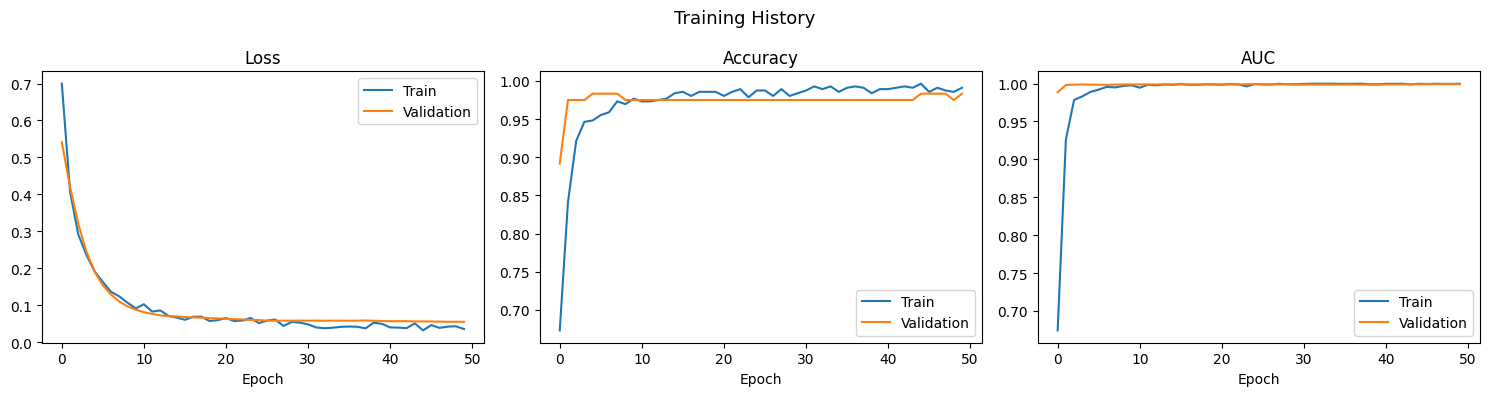

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('malaria_training_history.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 7: Evaluate on the test set

In [10]:
model.load_weights('best_malaria.keras')

test_results = model.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"{name:<12}: {value:.4f}")


loss        : 0.0291
compile_metrics: 1.0000


### ROC curve

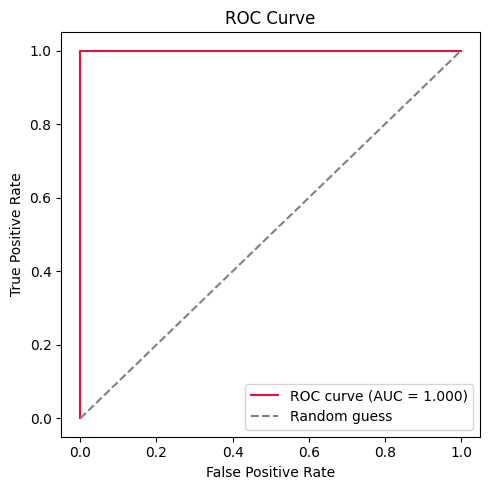

ROC-AUC: 1.0000


In [11]:
y_prob = model.predict(X_test, verbose=0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='crimson', label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('malaria_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")


### Classification report and confusion matrix

              precision    recall  f1-score   support

  No Malaria       1.00      1.00      1.00        70
     Malaria       1.00      1.00      1.00        50

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



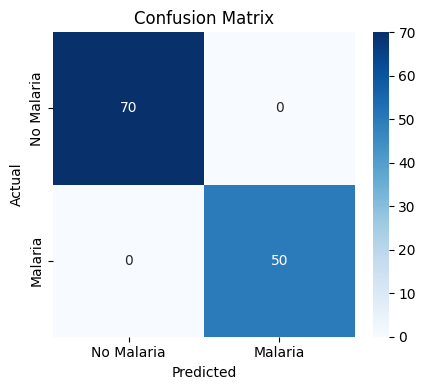

In [12]:
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['No Malaria', 'Malaria']))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Malaria', 'Malaria'],
            yticklabels=['No Malaria', 'Malaria'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('malaria_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 8: Save the trained model

In [13]:
model.save('malaria_ann.keras')

with open('malaria_inference_kit.pkl', 'wb') as f:
    pickle.dump({
        'feature_cols': feature_cols,
        'train_medians': train_medians,
        'scaler_mean': scaler_mean,
        'scaler_scale': scaler_scale,
    }, f)

print("Saved malaria_ann.keras")
print("Saved malaria_inference_kit.pkl")


Saved malaria_ann.keras
Saved malaria_inference_kit.pkl


## Step 9: Make a prediction on a new patient

Same clean, simple pattern as the diabetes notebook: engineer the same
features, scale by hand using the saved mean/scale, predict.

In [ ]:
def predict_patient(patient, model, feature_cols, scaler_mean, scaler_scale):
    patient = patient.copy()

    # Add the same extra features we created during data preparation
    patient['High_Fever'] = float(patient['Fever_Temp'] >= 38.0)
    patient['Fever_x_Chills'] = patient['Fever_Temp'] * patient['Chills']
    patient['Severe_Headache'] = float(patient['Headache_Severity'] >= 7)
    patient['Symptom_Count'] = (patient['Chills'] + patient['Vomiting'] + patient['Diarrhea']
                                 + patient['Sweating'] + patient['Nausea'])
    patient['Vulnerable_Age'] = float(patient['Age'] < 5 or patient['Age'] > 60)

    # Put the features in the exact same order the model expects
    row = np.array([patient[col] for col in feature_cols], dtype=np.float32)

    # Scale by hand, same formula the training data went through
    row_scaled = ((row - scaler_mean) / scaler_scale).reshape(1, -1)

    probability = model.predict(row_scaled, verbose=0)[0][0]
    prediction = 'Malaria' if probability >= 0.5 else 'No Malaria'

    print(f"Probability of malaria: {probability:.1%}")
    print(f"Prediction: {prediction}")


In [ ]:
patient_1 = {
    'Age': 6, 'Fever_Temp': 39.4, 'Chills': 1, 'Headache_Severity': 8.0,
    'Vomiting': 1, 'Diarrhea': 0, 'Muscle_Pain': 7.0, 'Fatigue_Level': 8.0,
    'Sweating': 1, 'Nausea': 1,
}
print("Patient 1 (strong malaria symptoms)")
predict_patient(patient_1, model, feature_cols, scaler_mean, scaler_scale)

print()

patient_2 = {
    'Age': 27, 'Fever_Temp': 36.9, 'Chills': 0, 'Headache_Severity': 2.0,
    'Vomiting': 0, 'Diarrhea': 0, 'Muscle_Pain': 1.5, 'Fatigue_Level': 2.5,
    'Sweating': 0, 'Nausea': 0,
}
print("Patient 2 (no notable symptoms)")
predict_patient(patient_2, model, feature_cols, scaler_mean, scaler_scale)


### Done

Same pipeline, same reasoning, a different disease. This is the pattern
you'll reuse for almost any tabular medical classification problem: clean
the data, engineer a few clinically-informed features, train a small ANN,
and evaluate with AUC/ROC rather than accuracy alone.